# H1.Z16 Raw 2023 STL View

DB raw 데이터 기준으로 `H1.Z16`의 2023년 1년치만 시각화합니다.  
전처리(`issue 마스킹`, `음수 제거`, `보간`) 전 상태를 기준으로 `P`, `PF`, `Ta`, `Igm` 흐름과 `P`의 STL 분해 결과를 함께 봅니다.

In [1]:
from pathlib import Path
import sys

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import Image, display
from statsmodels.tsa.seasonal import STL

PROJECT_ROOT = Path('/home/playdata2/final_pj/energy-platform')
SCRIPTS_DIR = PROJECT_ROOT / 'scripts'
OUTPUT_DIR = PROJECT_ROOT / 'outputs' / 'stl_raw_2023'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
if str(SCRIPTS_DIR) not in sys.path:
    sys.path.insert(0, str(SCRIPTS_DIR))

from scripts.fetch_h1z16_with_weather import build_engine, fetch_meter_data, fetch_weather_data

METER_URN = 'H1.Z16'
YEAR_START = pd.Timestamp('2023-01-01 00:00:00+00:00')
YEAR_END = pd.Timestamp('2023-12-31 23:59:59+00:00')
RAW_TS_PATH = OUTPUT_DIR / 'H1_Z16_raw_2023_timeseries.png'
RAW_STL_DECOMP_PATH = OUTPUT_DIR / 'H1_Z16_raw_2023_stl_decomposition.png'
RAW_STL_ANOM_PATH = OUTPUT_DIR / 'H1_Z16_raw_2023_stl_anomaly.png'

In [2]:
engine = build_engine()
df_main = fetch_meter_data(engine, METER_URN)
df_weather = fetch_weather_data(engine)
raw_df = df_main.merge(df_weather, on='ts', how='left').sort_values('ts').reset_index(drop=True)
year_df = raw_df.loc[raw_df['ts'].between(YEAR_START, YEAR_END)].copy()

print('raw full shape:', raw_df.shape)
print('raw 2023 shape:', year_df.shape)
print('columns:', year_df.columns.tolist())
print()
print('null counts:')
print(year_df[['P', 'PF', 'Ta', 'Igm']].isnull().sum())
year_df[['ts', 'P', 'PF', 'Ta', 'Igm']].head()

raw full shape: (52585, 23)
raw 2023 shape: (8760, 23)
columns: ['ts', 'meter_urn', 'P', 'W', 'PF', 'PF1', 'PF2', 'PF3', 'P1', 'P2', 'P3', 'I1', 'I2', 'I3', 'U1', 'U2', 'U3', 'Q', 'f', 'W_in', 'W_out', 'Ta', 'Igm']

null counts:
P      1
PF     1
Ta     1
Igm    1
dtype: int64


,ts,P,PF,Ta,Igm
43824,2023-01-01 00:00:00+00:00,437.946667,0.994,14.090628,0.000068
43825,2023-01-01 01:00:00+00:00,443.232500,0.994,13.641301,0.023780
43826,2023-01-01 02:00:00+00:00,448.542833,0.994,12.752359,0.000000
43827,2023-01-01 03:00:00+00:00,446.543500,0.994,11.426336,0.097874
43828,2023-01-01 04:00:00+00:00,446.990500,0.994,10.021378,0.020424


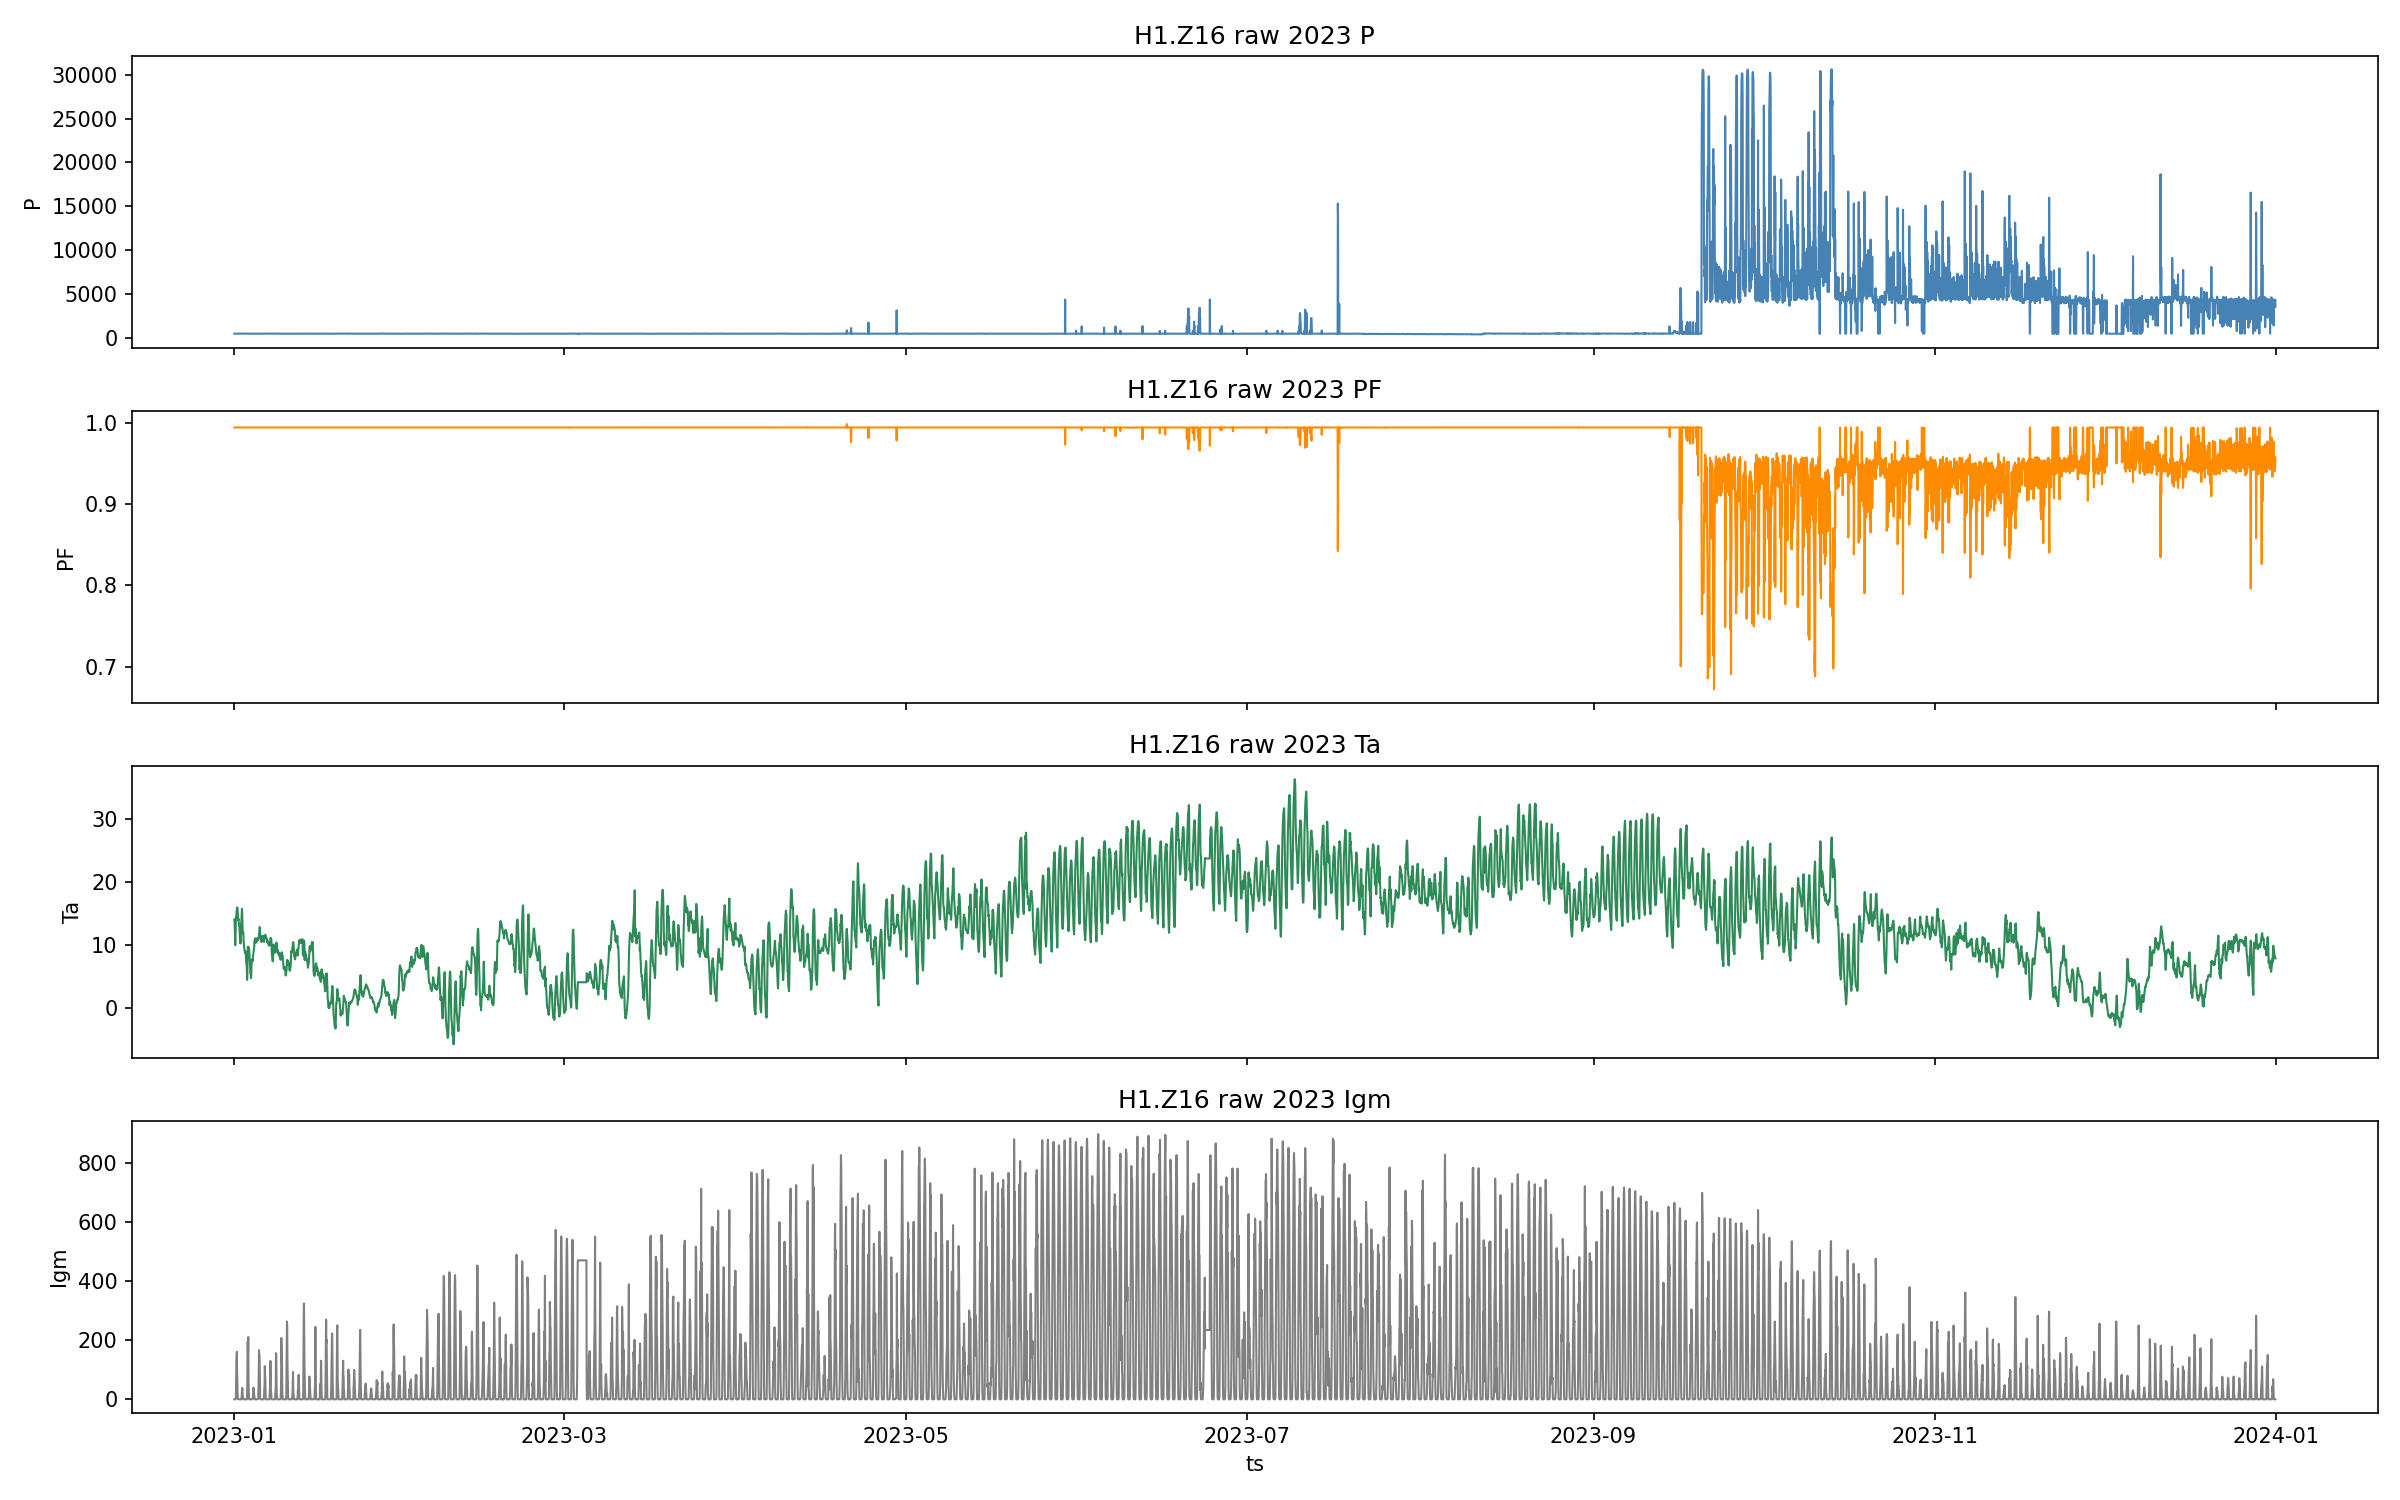

saved: /home/playdata2/final_pj/energy-platform/outputs/stl_raw_2023/H1_Z16_raw_2023_timeseries.png


In [3]:
fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
plot_cols = ['P', 'PF', 'Ta', 'Igm']
colors = ['steelblue', 'darkorange', 'seagreen', 'gray']

for ax, col, color in zip(axes, plot_cols, colors):
    axes_title = f'{METER_URN} raw 2023 {col}'
    ax.plot(year_df['ts'], year_df[col], color=color, linewidth=1)
    ax.set_title(axes_title)
    ax.set_ylabel(col)

axes[-1].set_xlabel('ts')
plt.tight_layout()
plt.savefig(RAW_TS_PATH, dpi=150)
plt.close(fig)

display(Image(filename=str(RAW_TS_PATH)))
print(f'saved: {RAW_TS_PATH}')

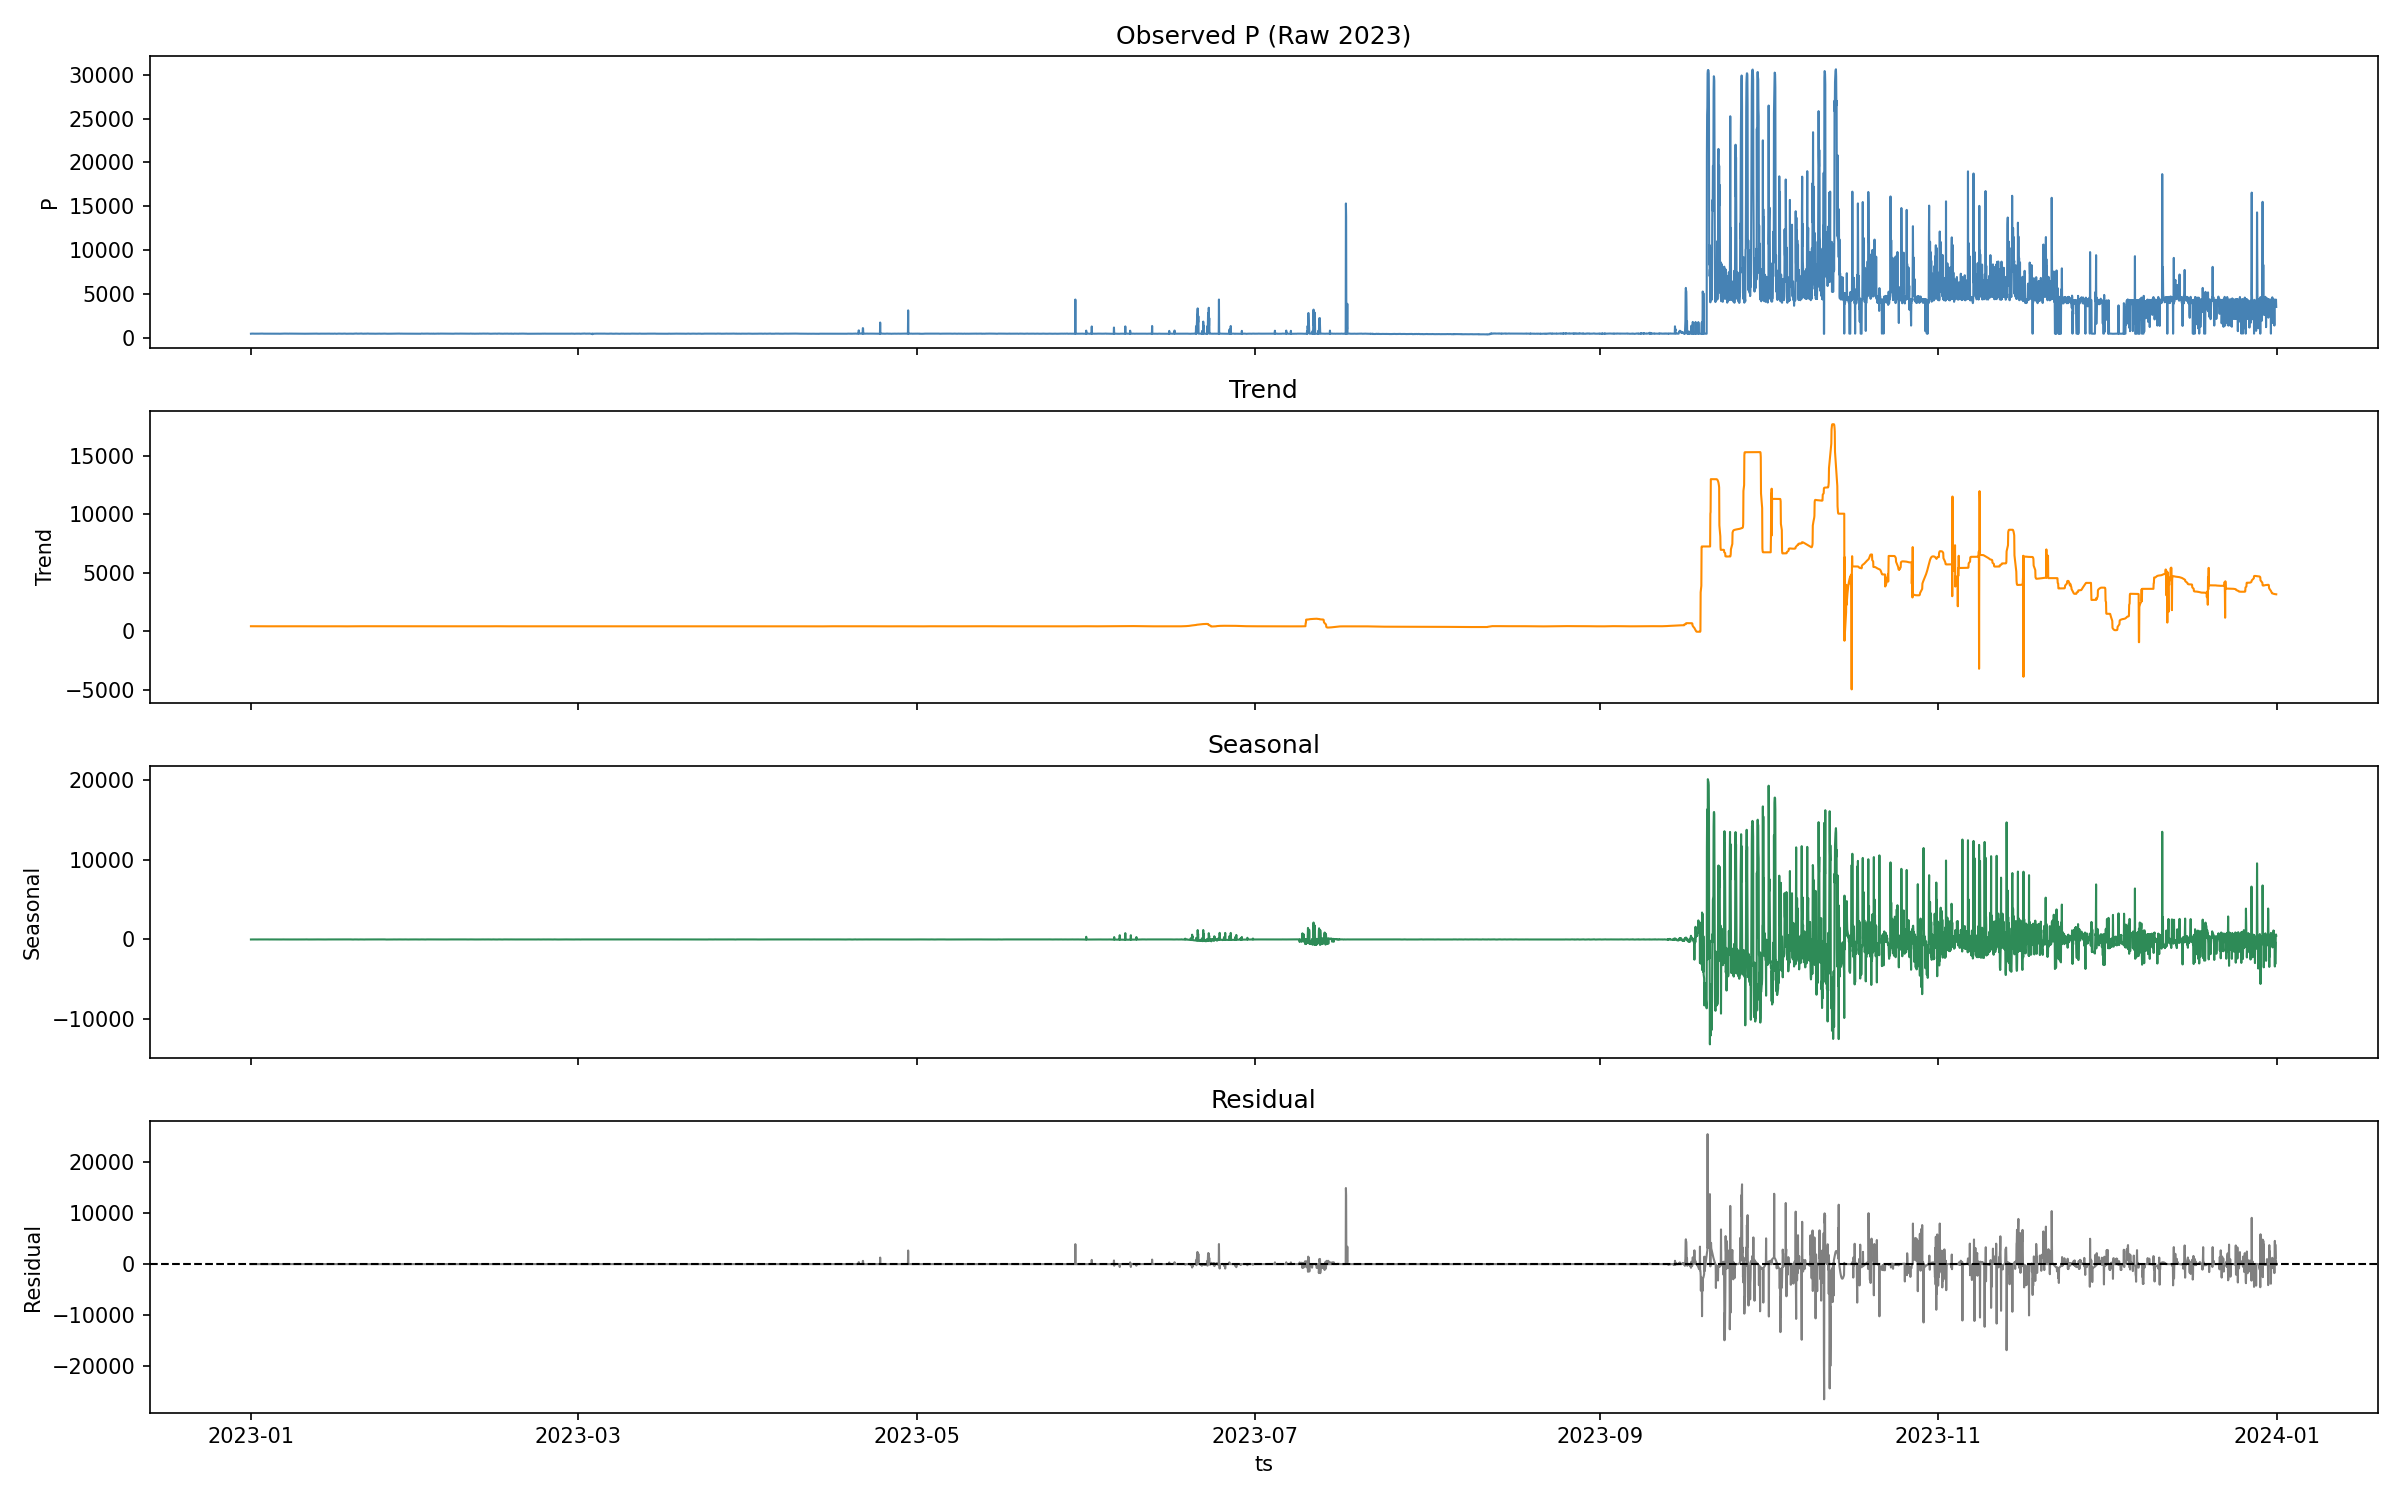

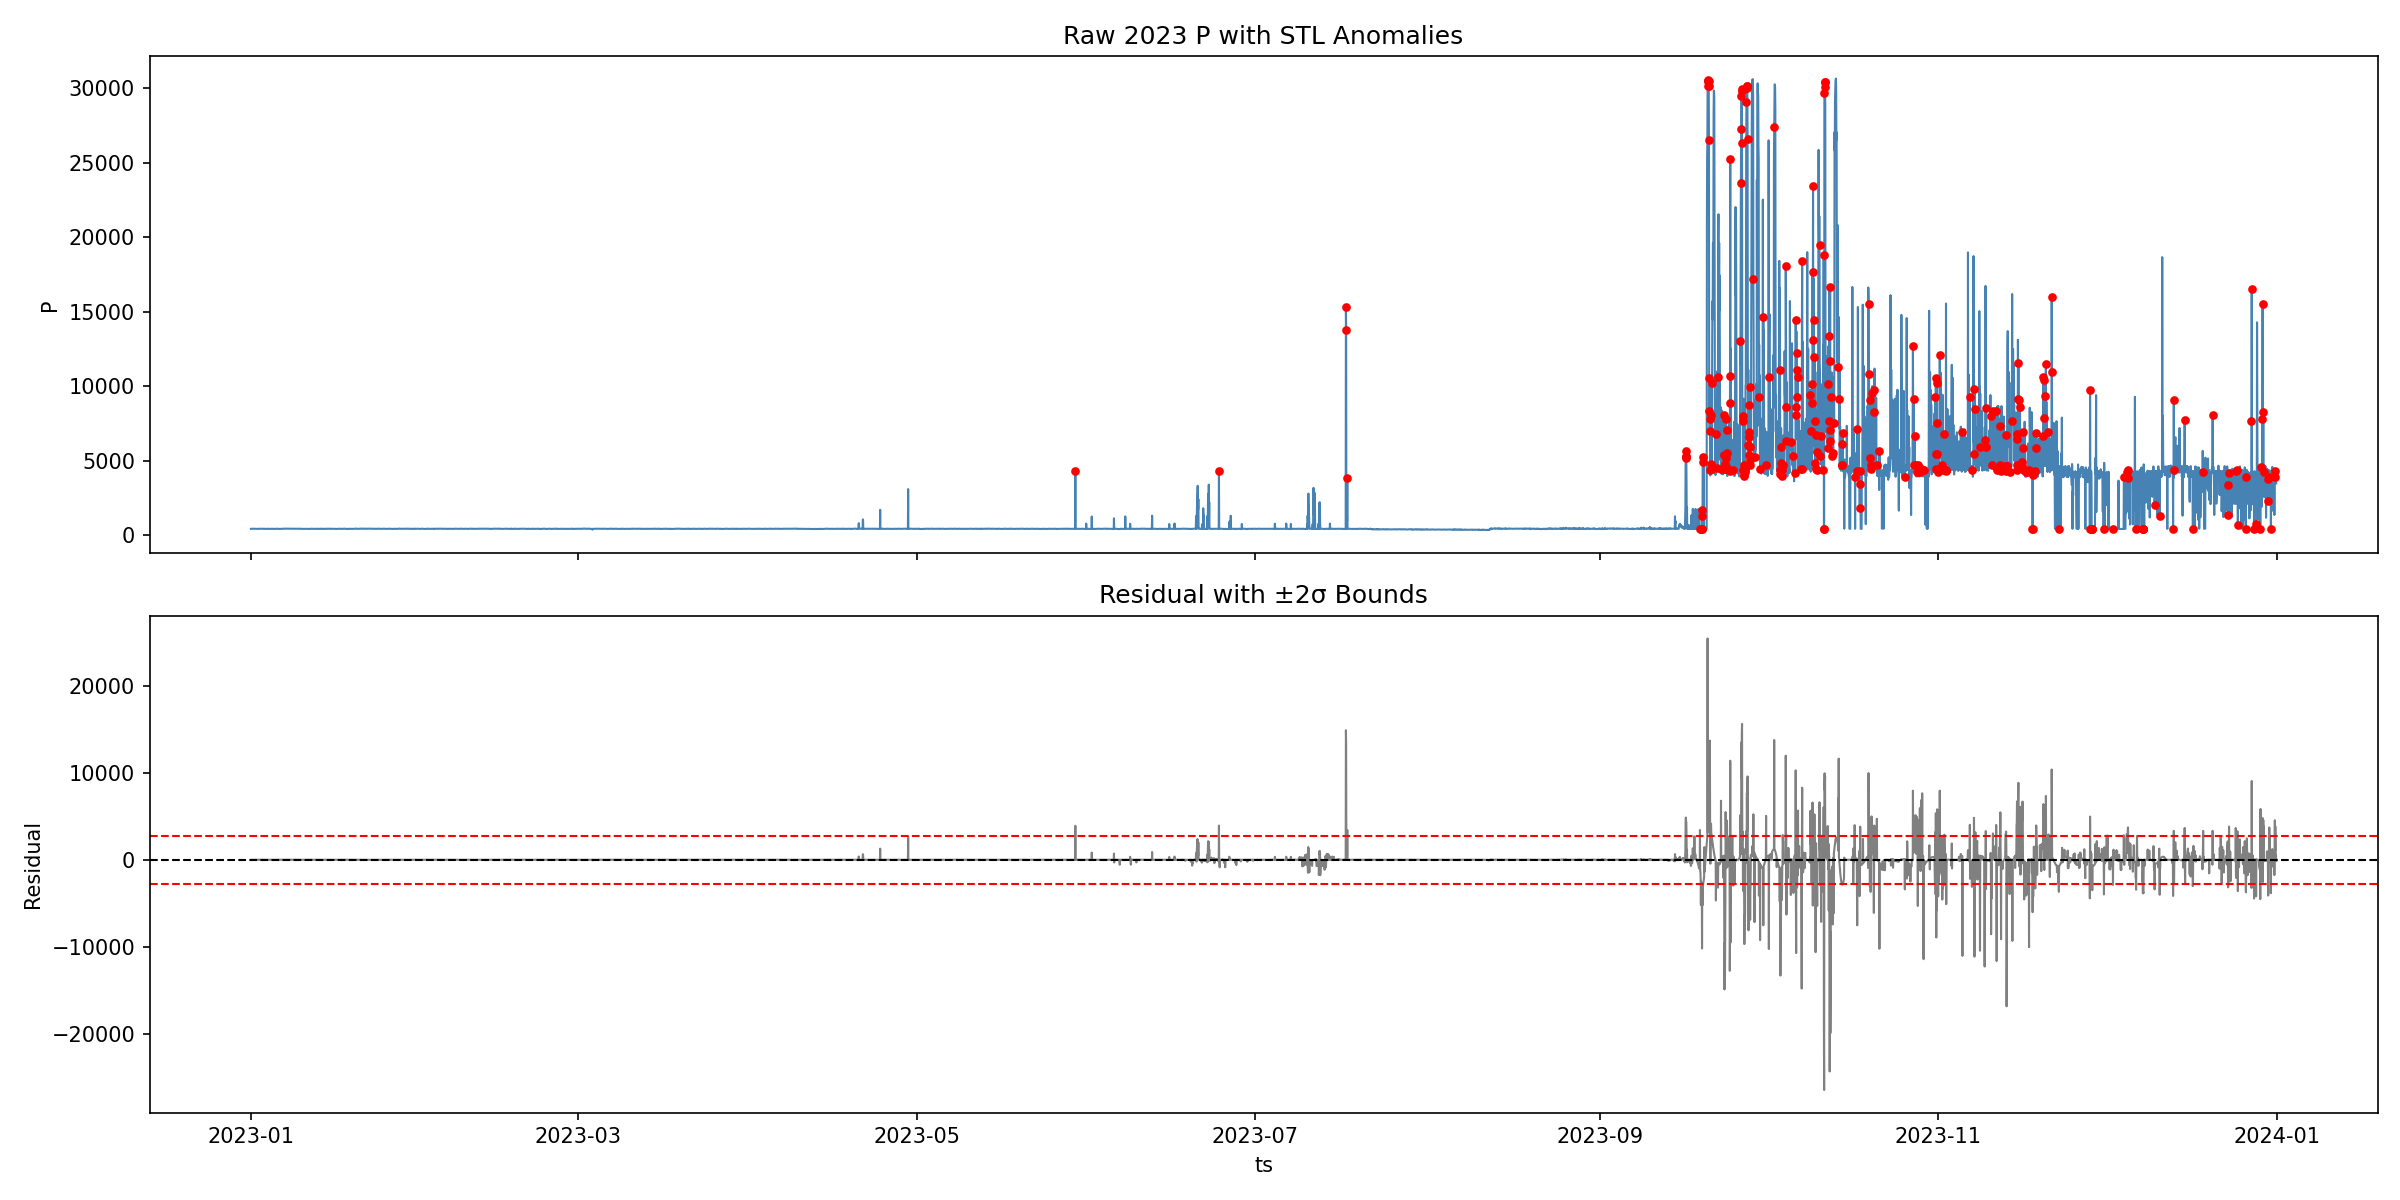

saved: /home/playdata2/final_pj/energy-platform/outputs/stl_raw_2023/H1_Z16_raw_2023_stl_decomposition.png
saved: /home/playdata2/final_pj/energy-platform/outputs/stl_raw_2023/H1_Z16_raw_2023_stl_anomaly.png


In [4]:
stl_input = year_df.loc[year_df['P'].notna(), ['ts', 'P']].copy().reset_index(drop=True)
stl = STL(stl_input['P'], period=24, seasonal=7, robust=True)
result = stl.fit()

stl_df = stl_input.copy()
stl_df['trend'] = result.trend
stl_df['seasonal'] = result.seasonal
stl_df['residual'] = result.resid

mu = stl_df['residual'].mean()
sigma = stl_df['residual'].std()
lower = mu - 2 * sigma
upper = mu + 2 * sigma
stl_df['anomaly_stl'] = (stl_df['residual'] < lower) | (stl_df['residual'] > upper)

fig, axes = plt.subplots(4, 1, figsize=(16, 10), sharex=True)
axes[0].plot(stl_df['ts'], stl_df['P'], color='steelblue', linewidth=1)
axes[0].set_title('Observed P (Raw 2023)')
axes[0].set_ylabel('P')
axes[1].plot(stl_df['ts'], stl_df['trend'], color='darkorange', linewidth=1)
axes[1].set_title('Trend')
axes[1].set_ylabel('Trend')
axes[2].plot(stl_df['ts'], stl_df['seasonal'], color='seagreen', linewidth=1)
axes[2].set_title('Seasonal')
axes[2].set_ylabel('Seasonal')
axes[3].plot(stl_df['ts'], stl_df['residual'], color='gray', linewidth=1)
axes[3].axhline(0.0, color='black', linestyle='--', linewidth=1)
axes[3].set_title('Residual')
axes[3].set_ylabel('Residual')
axes[3].set_xlabel('ts')
plt.tight_layout()
plt.savefig(RAW_STL_DECOMP_PATH, dpi=150)
plt.close(fig)

anom_df = stl_df.loc[stl_df['anomaly_stl']]
fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
axes[0].plot(stl_df['ts'], stl_df['P'], color='steelblue', linewidth=1)
axes[0].scatter(anom_df['ts'], anom_df['P'], color='red', s=10, zorder=3)
axes[0].set_title('Raw 2023 P with STL Anomalies')
axes[0].set_ylabel('P')
axes[1].plot(stl_df['ts'], stl_df['residual'], color='gray', linewidth=1)
axes[1].axhline(mu, color='black', linestyle='--', linewidth=1)
axes[1].axhline(lower, color='red', linestyle='--', linewidth=1)
axes[1].axhline(upper, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Residual with ±2σ Bounds')
axes[1].set_xlabel('ts')
axes[1].set_ylabel('Residual')
plt.tight_layout()
plt.savefig(RAW_STL_ANOM_PATH, dpi=150)
plt.close(fig)

display(Image(filename=str(RAW_STL_DECOMP_PATH)))
display(Image(filename=str(RAW_STL_ANOM_PATH)))
print(f'saved: {RAW_STL_DECOMP_PATH}')
print(f'saved: {RAW_STL_ANOM_PATH}')

In [5]:
anomaly_ratio = len(stl_df.loc[stl_df['anomaly_stl']]) / len(stl_df) if len(stl_df) else 0.0
print('raw 2023 STL rows:', len(stl_df))
print(f'raw 2023 anomaly count: {stl_df["anomaly_stl"].sum()} ({anomaly_ratio:.2%})')
stl_df.loc[stl_df['anomaly_stl'], ['ts', 'P', 'residual']].head(10)

raw 2023 STL rows: 8759
raw 2023 anomaly count: 317 (3.62%)


,ts,P,residual
3565,2023-05-29 13:00:00+00:00,4340.512500,3899.556473
4186,2023-06-24 10:00:00+00:00,4342.149167,3921.485521
4735,2023-07-17 07:00:00+00:00,15309.104333,14873.007475
4736,2023-07-17 08:00:00+00:00,13794.968500,13358.610331
4741,2023-07-17 13:00:00+00:00,3853.678250,3410.703718
6204,2023-09-16 12:00:00+00:00,5169.813025,4370.923056
6205,2023-09-16 13:00:00+00:00,5669.020946,4848.035690
6206,2023-09-16 14:00:00+00:00,5341.152349,4407.136464
6207,2023-09-16 15:00:00+00:00,5240.962563,4353.911706
6266,2023-09-19 02:00:00+00:00,429.500667,3417.908762
